In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
solar_data = pd.read_csv(r"C:\Users\aleks\Downloads\solarpower\solarpower.csv")
solar_data.head()

,date,cum_power
0,2017-01-01,20111.0
1,2017-01-02,20112.0
2,2017-01-03,20115.0
3,2017-01-04,20117.0
4,2017-01-05,20119.0


In [4]:
for i in range(1, len(solar_data) - 1):
    if solar_data.loc[i, 'cum_power'] == -1:
        solar_data.loc[i, 'cum_power'] = (
            solar_data.loc[i - 1, 'cum_power'] + solar_data.loc[i + 1, 'cum_power']
        ) / 2

answer = round(solar_data['cum_power'].mean())
print(answer)

23848


In [ ]:
for i in range(1, len(solar_data) - 1):
    if solar_data.loc[i, 'cum_power'] == -1:
        solar_data.loc[i, 'cum_power'] = (solar_data.loc[i - 1, 'cum_power'] + solar_data.loc[i + 1, 'cum_power']) / 2

solar_data['date'] = pd.to_datetime(solar_data['date'])
solar_data['day_power'] = solar_data['cum_power'].diff()

solar_data['month'] = solar_data['date'].dt.to_period('M')
monthly_mean = solar_data.groupby('month')['day_power'].mean()

answer = round(monthly_mean['2017-03'])
print(answer)

11


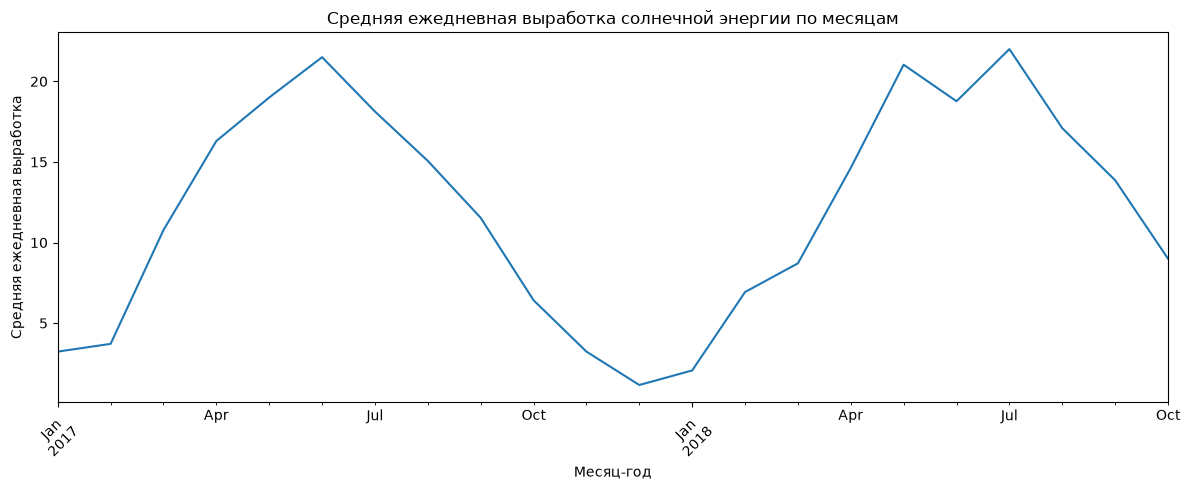

In [7]:

for i in range(1, len(solar_data) - 1):
    if solar_data.loc[i, 'cum_power'] == -1:
        solar_data.loc[i, 'cum_power'] = (
            solar_data.loc[i - 1, 'cum_power'] + solar_data.loc[i + 1, 'cum_power']
        ) / 2

solar_data['date'] = pd.to_datetime(solar_data['date'])
solar_data['day_power'] = solar_data['cum_power'].diff()

monthly = solar_data.groupby(solar_data['date'].dt.to_period('M'))['day_power'].mean()

plt.figure(figsize=(12, 5))
monthly.plot()
plt.title('Средняя ежедневная выработка солнечной энергии по месяцам')
plt.xlabel('Месяц-год')
plt.ylabel('Средняя ежедневная выработка')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()